# Corrected record: every paper number checked (demo)

This notebook is a runnable demo of the **claim checker** behind the iteration-4 paper's *corrected record*. The paper is about gold-free metrics for NL→FOL faithfulness. The artifact
(`eval.py`) re-reads **every number** quoted in the hypothesis (§0.2–0.3) and in the reviewer's 11 critiques
from the source result files, then compares it with the number printed in the paper draft.

- **Hypothesis vs file**: every claim literal is compared with the file value at the literal's own precision
  (`|claim − source| ≤ 0.5·10^-d`; a CI matches only if both bounds match). Statuses are MATCH, MISMATCH, NOT_FOUND and AMBIGUOUS.
- **Paper vs file**: the same number is looked up in the paper draft (within the section named by the claim) and
  checked against the file value. In the full run all 244 claims MATCH their files, and **15 paper numbers
  MISMATCH** (for example, all six §4.2 CIs are narrower than the source CIs).
- **Mutation test**: a checker that cannot fail proves nothing. The test injects 10 perturbed claims, which must all be caught, and re-checks 10 untouched claims, which must all MATCH.

**What the demo runs.** The full pipeline reads about 45 result files from the whole research run tree. It then builds `record_final.md`,
the lints, the claims ledger, the iteration-5 skeleton, figures F1–F4 and an independent audit. This demo uses `mini_demo_data.json`, which holds
**100 of the 502 checked rows**: 80 claims (including all 15 paper mismatches and every mutation-test claim) and 20 transcription rows.
It also holds a *pruned copy of each source file*, keeping only the JSON keys, CSV rows and text lines that the locators read, plus the
paper draft and the review critiques. The checker code below is the original code. The only change is that `_read_text` reads
from this bundle instead of from disk. Steps that need the full run tree are summarised from the reference results in the bundle.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, matplotlib, PyYAML — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'PyYAML==6.0.3')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports

The import block of `eval.py` and of the `src/` modules it uses, plus `pandas` and `matplotlib` for the final display.
The original sets `WS = Path(__file__).parent`. In a notebook, output files go to `./demo_out/` instead.

In [2]:
from __future__ import annotations

import csv
import copy
import hashlib
import io
import json
import math
import re
import subprocess
import sys
import time
import types
from collections import Counter
from pathlib import Path
from typing import Any

from loguru import logger

import pandas as pd
import matplotlib.pyplot as plt

WS = Path.cwd() / "demo_out"   # original: Path(__file__).resolve().parent
(WS / "logs").mkdir(parents=True, exist_ok=True)
(WS / "tables").mkdir(exist_ok=True)
(WS / "audit").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(WS / "logs/run.log", rotation="30 MB", level="DEBUG")

2

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/main/round-5/evaluation-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(f"{len(data['claims'])} claims, {len(data['transcriptions'])} transcription rows, {len(data['sources'])} pruned source files")

Mini bundle for the corrected-record claim checker: 80 hypothesis/review claims + 20 transcription rows (100 of 502), the pruned source cells their locators read, the paper draft and review critiques, plus reference results of the full original run.
80 claims, 20 transcription rows, 32 pruned source files


## Config

The number of claim rows to check. The original checks all 244 claims and 258 transcription rows. The mini bundle holds 80 + 20,
and checking them takes well under a second, so the demo uses all of them.
`RUN_MUTATION_TEST` runs the original 20-claim mutation test on the bundle's claims.

In [5]:
MAX_CLAIMS = 80        # hypothesis/review claims to check (bundle has 80; original run: 244)
MAX_TRANSCRIBED = 20   # transcription rows to check (bundle has 20; original run: 258)
RUN_MUTATION_TEST = True

## `src/io_locators.py`: reading one value from a source file

Every number in the corrected record is pulled through a **locator**, a small dict such as
`{"t": "json", "f": <file>, "k": <dotted key>}`, `{"t": "csv", "where": {...}, "col": ...}`, `regex`, `jsonl_count`, `ledger`,
or an `expr` that combines other locators arithmetically. No number is ever typed by hand. Every file read is hashed.

The code is original except for two lines. `RUN` is now relative, and `_read_text` reads from `data["sources"]`, the pruned copies of the files, instead of from disk.

In [6]:
RUN = data["run_root"]  # original: absolute path of the run tree; the bundle keys are relative to it
I3 = f"{RUN}/iter_3/gen_art"
I4 = f"{RUN}/iter_4/gen_art"
PAPER = f"{RUN}/iter_4/gen_report_text/gen_report_text/paper_draft.md"
REVIEW = f"{RUN}/iter_4/review_report/review_report/.terminal_claude_agent_struct_out.json"

HASHES: dict[str, str] = {}
_JSON_CACHE: dict[str, Any] = {}
_TEXT_CACHE: dict[str, str] = {}


class NotFound(Exception):
    """The file or the key does not exist."""


class Ambiguous(Exception):
    """More than one candidate cell matched."""


def _read_text(path: str) -> str:
    if path not in _TEXT_CACHE:
        # demo change: read the (pruned) source file from the loaded bundle instead of from disk
        if path not in data["sources"]:
            raise NotFound(f"source missing: {path}")
        b = data["sources"][path].encode("utf-8")
        HASHES[path] = hashlib.sha256(b).hexdigest()
        _TEXT_CACHE[path] = b.decode("utf-8", errors="replace")
    return _TEXT_CACHE[path]


def _load_json(path: str) -> Any:
    if path not in _JSON_CACHE:
        _JSON_CACHE[path] = json.loads(_read_text(path))
    return _JSON_CACHE[path]


def _walk_key(obj: Any, key: str) -> Any:
    """Resolve a dotted key where individual keys may themselves contain dots/spaces.

    At each level the longest prefix of the remaining path that is a key is taken.
    List indices are written as [i] directly after a key or as a bare integer part.
    """
    rest = key
    cur = obj
    while rest:
        m = re.match(r"^\[(\d+)\]\.?", rest)
        if m and isinstance(cur, list):
            cur = cur[int(m.group(1))]
            rest = rest[m.end():]
            continue
        if isinstance(cur, list):
            m = re.match(r"^(\d+)\.?", rest)
            if not m:
                raise NotFound(f"list index expected at '{rest}'")
            cur = cur[int(m.group(1))]
            rest = rest[m.end():]
            continue
        if not isinstance(cur, dict):
            raise NotFound(f"cannot descend into {type(cur).__name__} at '{rest}'")
        hit = None
        for k in sorted(cur.keys(), key=len, reverse=True):
            if rest == k or rest.startswith(k + ".") or rest.startswith(k + "["):
                hit = k
                break
        if hit is None:
            raise NotFound(f"key not found at '{rest[:60]}'")
        cur = cur[hit]
        rest = rest[len(hit):]
        if rest.startswith("."):
            rest = rest[1:]
    return cur


def json_key(path: str, dotted_key: str) -> tuple[Any, str]:
    return _walk_key(_load_json(path), dotted_key), f"{path} :: {dotted_key}"


def _csv_rows(path: str) -> list[dict[str, str]]:
    text = _read_text(path)
    lines = [ln for ln in text.splitlines() if not ln.startswith("# source") and not ln.startswith("#")]
    return list(csv.DictReader(io.StringIO("\n".join(lines))))


def csv_cell(path: str, row_filter: dict[str, str], col: str) -> tuple[Any, str]:
    rows = [r for r in _csv_rows(path) if all(str(r.get(k, "")) == str(v) for k, v in row_filter.items())]
    if not rows:
        raise NotFound(f"no csv row {row_filter} in {path}")
    vals = {r.get(col) for r in rows}
    if len(vals) > 1:
        raise Ambiguous(f"{len(rows)} rows with differing '{col}' for {row_filter}")
    if col not in rows[0]:
        raise NotFound(f"column {col} missing in {path}")
    filt = ", ".join(f"{k}={v}" for k, v in row_filter.items())
    return rows[0][col], f"{path} :: row[{filt}] col[{col}]"


def md_table_cell(path: str, table_heading: str, row_regex: str, col_index: int) -> tuple[Any, str]:
    """Fallback reader for markdown tables (used only when no machine source exists)."""
    text = _read_text(path)
    start = text.find(table_heading)
    if start < 0:
        raise NotFound(f"heading '{table_heading}' not in {path}")
    nxt = re.search(r"\n#{2,3} ", text[start + len(table_heading):])
    block = text[start: start + len(table_heading) + (nxt.start() if nxt else len(text))]
    rows = [ln for ln in block.splitlines() if ln.startswith("|") and re.search(row_regex, ln)]
    if not rows:
        raise NotFound(f"row /{row_regex}/ not in table '{table_heading}'")
    if len(rows) > 1:
        raise Ambiguous(f"{len(rows)} rows match /{row_regex}/")
    cells = [c.strip() for c in rows[0].strip().strip("|").split("|")]
    return cells[col_index], f"{path} :: table '{table_heading}' row /{row_regex}/ col {col_index}"


def regex(path: str, pattern: str, group: int = 1) -> tuple[Any, str]:
    text = _read_text(path)
    ms = list(re.finditer(pattern, text, flags=re.M))
    if not ms:
        raise NotFound(f"/{pattern}/ not in {path}")
    vals = {m.group(group) for m in ms}
    if len(vals) > 1:
        raise Ambiguous(f"/{pattern}/ matched {len(ms)} differing values")
    return ms[0].group(group), f"{path} :: regex /{pattern}/ group {group}"


def jsonl_count(path: str, where: dict[str, Any]) -> tuple[int, str]:
    text = _read_text(path)
    n = 0
    for ln in text.splitlines():
        if not ln.strip():
            continue
        r = json.loads(ln)
        if all(r.get(k) == v for k, v in where.items()):
            n += 1
    return n, f"{path} :: count rows where {where}"


def ledger_sum(path: str, field: str = "cost_usd") -> tuple[float, str]:
    text = _read_text(path)
    s = 0.0
    for ln in text.splitlines():
        if ln.strip():
            try:
                s += float(json.loads(ln).get(field) or 0.0)
            except (json.JSONDecodeError, TypeError, ValueError):
                continue
    return s, f"{path} :: sum({field})"


def to_float(v: Any) -> float:
    if isinstance(v, bool):
        return float(v)
    if isinstance(v, (int, float)):
        return float(v)
    s = str(v).strip().replace("−", "-").replace(",", "").replace("$", "")
    m = re.search(r"-?\d+(?:\.\d+)?(?:e-?\d+)?", s)
    if not m:
        raise ValueError(f"no number in {v!r}")
    return float(m.group(0))


def resolve(loc: dict[str, Any]) -> tuple[Any, str]:
    """Resolve a locator dict to (value, locator_string)."""
    t = loc["t"]
    if t == "json":
        v, s = json_key(loc["f"], loc["k"])
    elif t == "csv":
        v, s = csv_cell(loc["f"], loc["where"], loc["col"])
    elif t == "md":
        v, s = md_table_cell(loc["f"], loc["h"], loc["row"], loc["col"])
    elif t == "regex":
        v, s = regex(loc["f"], loc["pat"], loc.get("g", 1))
    elif t == "jsonl_count":
        v, s = jsonl_count(loc["f"], loc["where"])
    elif t == "ledger":
        v, s = ledger_sum(loc["f"], loc.get("field", "cost_usd"))
    elif t == "expr":
        env = {}
        parts = []
        for name, sub in loc["args"].items():
            val, sloc = resolve(sub)
            env[name] = to_float(val)
            parts.append(f"{name}={sloc}")
        v = eval(loc["expr"], {"__builtins__": {}}, env)  # noqa: S307 - arithmetic on file values only
        s = f"expr[{loc['expr']}] with " + " ; ".join(parts)
    elif t == "const":
        v, s = loc["v"], f"CONTEXT (no file value): {loc.get('why', '')}"
    else:
        raise ValueError(f"unknown locator type {t}")
    if "idx" in loc:
        v = v[loc["idx"]]
        s += f" [{loc['idx']}]"
    return v, s


# the original imports this file as a module (`from src import io_locators as L`); expose the same names as `L`
L = types.SimpleNamespace(**{k: globals()[k] for k in [
    "RUN", "I3", "I4", "PAPER", "REVIEW", "HASHES", "NotFound", "Ambiguous", "_read_text", "_load_json", "_walk_key",
    "json_key", "_csv_rows", "csv_cell", "md_table_cell", "regex", "jsonl_count", "ledger_sum", "to_float", "resolve"]})
print("PAPER =", L.PAPER, "| in bundle:", L.PAPER in data["sources"])

PAPER = 3_invention_loop/iter_4/gen_report_text/gen_report_text/paper_draft.md | in bundle: True


## `src/checker.py`: the precision rule and the paper lookup

- `parse_literal` turns a claim literal such as `0.614`, `44.9%`, `−$1.58` or `2.4e−5` into (value, tolerance). The tolerance is half a unit
  in the literal's last digit. Percentages are compared as fractions.
- `num_match` also requires the signs to agree.
- `check_claim` resolves the claim's locator (and its CI locator), then compares hypothesis vs file.
  On the paper side, it either greps the literal inside the claimed paper section (`ps`) or, when the review says the paper printed a
  *different* number, extracts the paper's own number with the regex `pp` and compares that with the file.

This cell is the original code verbatim, apart from the import line.

In [7]:
NUM_RE = r"[+\-−]?\$?\d[\d,]*(?:\.\d+)?(?:e[+\-−]?\d+)?%?"


def norm(s: str) -> str:
    return s.replace("−", "-").replace("−", "-").strip()


def is_numeric_literal(s: str) -> bool:
    return bool(re.fullmatch(r"[+\-]?\$?\d[\d,]*(?:\.\d+)?(?:e[+\-]?\d+)?%?", norm(s)))


def parse_literal(s: str) -> tuple[float, float, dict]:
    """Return (value_as_fraction_or_number, tolerance, format_info)."""
    t = norm(s)
    info = {"sign": t.startswith("+"), "pct": t.endswith("%"), "usd": "$" in t, "sci": "e" in t.lower()}
    core = t.replace("$", "").replace(",", "").rstrip("%").lstrip("+")
    if info["sci"]:
        mant, exp = core.lower().split("e")
        dec = len(mant.split(".")[1]) if "." in mant else 0
        val = float(core)
        tol = 0.5 * 10 ** (-dec) * 10 ** int(exp)
        info["dec"], info["exp"] = dec, int(exp)
    else:
        dec = len(core.split(".")[1]) if "." in core else 0
        val = float(core)
        tol = 0.5 * 10 ** (-dec)
        info["dec"] = dec
    if info["pct"]:
        val /= 100.0
        tol /= 100.0
    info["thousands"] = "," in t
    return val, tol * (1 + 1e-9) + 1e-12, info


def parse_ci(s: str) -> list[str]:
    parts = [p.strip() for p in norm(s).strip("[]").split(",")]
    if len(parts) != 2:
        raise ValueError(f"bad CI literal {s}")
    return parts


def fmt_like(v: float, claim_literal: str) -> str:
    """Format a file value at the claim literal's precision/style (display only)."""
    _, _, info = parse_literal(claim_literal)
    x = v * 100.0 if info["pct"] else v
    if info.get("sci"):
        body = f"{x / 10 ** info['exp']:.{info['dec']}f}e{info['exp']}"
    elif info["thousands"]:
        body = f"{x:,.{info['dec']}f}"
    else:
        body = f"{x:.{info['dec']}f}"
    if body.startswith("-"):
        body = "−" + body[1:]
    elif info["sign"] and x > 0:
        body = "+" + body
    if info["usd"]:
        body = ("−$" + body[1:]) if body.startswith("−") else "$" + body
    return body + ("%" if info["pct"] else "")


def fmt_ci_like(ci: list[float], claim_ci: str) -> str:
    lo_l, hi_l = parse_ci(claim_ci)
    return f"[{fmt_like(ci[0], lo_l)}, {fmt_like(ci[1], hi_l)}]"


def num_match(claim_literal: str, source: float) -> bool:
    val, tol, _ = parse_literal(claim_literal)
    if val != 0 and source != 0 and math.copysign(1, val) != math.copysign(1, source) and abs(source) > tol:
        return False
    return abs(val - source) <= tol


def split_value_ci(v: Any) -> tuple[Any, list[float] | None]:
    """A source cell like '0.278 [0.239, 0.319]' carries its own CI."""
    if isinstance(v, str) and "[" in v:
        m = re.match(r"\s*([^\[]+)\[([^,]+),([^\]]+)\]", v)
        if m:
            return m.group(1).strip(), [L.to_float(m.group(2)), L.to_float(m.group(3))]
    return v, None


def _get_ci(ciloc: Any) -> tuple[list[float], str]:
    if isinstance(ciloc, list):
        (lo, s1), (hi, s2) = L.resolve(ciloc[0]), L.resolve(ciloc[1])
        return [L.to_float(lo), L.to_float(hi)], f"{s1} ; {s2}"
    v, s = L.resolve(ciloc)
    return [L.to_float(v[0]), L.to_float(v[1])], s


# ---------------------------------------------------------------- paper helpers
_PAPER_LINES: list[str] | None = None


def paper_lines() -> list[str]:
    global _PAPER_LINES
    if _PAPER_LINES is None:
        _PAPER_LINES = L._read_text(L.PAPER).splitlines()
    return _PAPER_LINES


def section_range(prefix: str | None) -> tuple[int, int]:
    """1-based inclusive line range of the paper section whose heading starts with prefix."""
    lines = paper_lines()
    if not prefix:
        return 1, len(lines)
    for i, ln in enumerate(lines):
        if ln.startswith(prefix):
            level = len(ln) - len(ln.lstrip("#"))
            for j in range(i + 1, len(lines)):
                m = re.match(r"^(#+) ", lines[j])
                if m and len(m.group(1)) <= level:
                    return i + 1, j
            return i + 1, len(lines)
    return 1, len(lines)


def headings() -> list[tuple[int, str]]:
    return [(i + 1, ln) for i, ln in enumerate(paper_lines()) if re.match(r"^#+ ", ln)]


def literal_variants(lit: str) -> list[str]:
    t = norm(lit)
    out = {t, t.lstrip("+"), t.replace("-", "−"), t.lstrip("+").replace("-", "−")}
    if t.endswith("%"):
        v = float(t.rstrip("%").replace(",", "")) / 100
        out.add(f"{v:.3f}".rstrip("0"))
    return sorted(out, key=len, reverse=True)


def grep_paper(lit: str, prefix: str | None) -> tuple[str | None, int | None]:
    lo, hi = section_range(prefix)
    lines = paper_lines()
    for var in literal_variants(lit):
        pat = r"(?<![\d.])" + re.escape(var) + r"(?![\d])"
        for i in range(lo - 1, hi):
            if re.search(pat, lines[i]):
                return var, i + 1
    return None, None


def paper_pattern(pp: Any, prefix: str | None) -> tuple[str | None, int | None]:
    pat, grp = (pp, 1) if isinstance(pp, str) else pp
    lo, hi = section_range(prefix)
    lines = paper_lines()
    for i in range(lo - 1, hi):
        m = re.search(pat, lines[i])
        if m:
            return m.group(grp), i + 1
    return None, None


# ---------------------------------------------------------------- main check
def check_claim(cl: dict) -> dict:
    row = {k: cl.get(k) for k in ("id", "sec", "text", "value", "ci", "role", "ps")}
    row.update(source_path="", locator="", source_value="", source_ci="", match_hyp_vs_file="", paper_value="",
               paper_line="", match_paper_vs_file="", note="", source_value_raw=None, source_ci_raw=None)
    try:
        v, s = L.resolve(cl["loc"])
        row["locator"] = s
        row["source_path"] = s.split(" :: ")[0] if " :: " in s else s
        v, inline_ci = split_value_ci(v)
        ci_src = None
        if cl.get("ciloc"):
            ci_src, cs = _get_ci(cl["ciloc"])
            row["locator"] += f" || CI: {cs}"
        elif inline_ci is not None:
            ci_src = inline_ci
        if cl["loc"]["t"] == "const":
            row["note"] = "CONTEXT: no file value; " + cl["loc"].get("why", "")
        if cl["value"] is None:  # transcription row: value read by code, no claim literal
            fv = L.to_float(v)
            row["source_value_raw"] = fv
            fmt = cl.get("fmt", "0.000")
            row["source_value"] = (re.sub(r"e([+-])0*(\d)", lambda m: "e" + ("−" if m.group(1) == "-" else "") + m.group(2), f"{fv:.2e}") if fmt == "0.00e0" else fmt_like(fv, fmt))
            ok = True
        elif is_numeric_literal(cl["value"]):
            fv = L.to_float(v)
            row["source_value_raw"] = fv
            row["source_value"] = fmt_like(fv, cl["value"])
            ok = num_match(cl["value"], fv)
        else:
            row["source_value"] = str(v)
            row["source_value_raw"] = str(v)
            ok = str(v) == cl["value"]
        if cl.get("ci") and cl["value"] is None:
            if ci_src is not None:
                row["source_ci_raw"] = ci_src
                row["source_ci"] = fmt_ci_like(ci_src, cl["ci"])
        elif cl.get("ci"):
            if ci_src is None:
                if cl["id"] == "t1_vs_s4":  # CI of S4-c, sign-flipped
                    raw, cs = L.resolve({"t": "json", "f": cl["loc"]["args"]["a"]["f"],
                                         "k": cl["loc"]["args"]["a"]["k"][: -len(".delta")] + ".ci"})
                    ci_src = [-L.to_float(raw[1]), -L.to_float(raw[0])]
                    row["locator"] += f" || CI (negated, bounds swapped): {cs}"
                else:
                    row["note"] += " CI not in source;"
            if ci_src is not None:
                row["source_ci_raw"] = ci_src
                row["source_ci"] = fmt_ci_like(ci_src, cl["ci"])
                lo_l, hi_l = parse_ci(cl["ci"])
                ok = ok and num_match(lo_l, ci_src[0]) and num_match(hi_l, ci_src[1])
        elif ci_src is not None:
            row["source_ci_raw"] = ci_src
            row["source_ci"] = f"[{ci_src[0]:.3f}, {ci_src[1]:.3f}]".replace("-", "−")
        row["match_hyp_vs_file"] = ("TRANSCRIBED" if cl["value"] is None else ("MATCH" if ok else "MISMATCH"))
    except L.NotFound as e:
        row["match_hyp_vs_file"] = "NOT_FOUND"
        row["note"] += str(e)[:200]
        return row
    except L.Ambiguous as e:
        row["match_hyp_vs_file"] = "AMBIGUOUS"
        row["note"] += str(e)[:200]
        return row
    # paper side
    if cl["value"] is None:
        row["match_paper_vs_file"] = "n/a"
        return row
    if cl.get("pp"):
        pv, line = paper_pattern(cl["pp"], cl.get("ps"))
        if pv is None:
            row["paper_value"], row["match_paper_vs_file"] = "", "NOT_IN_PAPER"
        else:
            row["paper_value"], row["paper_line"] = pv, line
            if pv.startswith("["):
                lo_l, hi_l = parse_ci(pv)
                okp = row["source_ci_raw"] is not None and num_match(lo_l, row["source_ci_raw"][0]) and num_match(hi_l, row["source_ci_raw"][1])
            elif is_numeric_literal(pv) and isinstance(row["source_value_raw"], float):
                okp = num_match(pv, row["source_value_raw"])
            else:
                okp = pv == str(row["source_value_raw"])
            row["match_paper_vs_file"] = "MATCH" if okp else "MISMATCH"
    else:
        var, line = grep_paper(cl["value"], cl.get("ps")) if is_numeric_literal(cl["value"]) else (None, None)
        if var is None:
            row["match_paper_vs_file"] = "NOT_IN_PAPER"
        else:
            row["paper_value"], row["paper_line"] = var, line
            row["match_paper_vs_file"] = row["match_hyp_vs_file"]
    return row


def check_all(claims: list[dict]) -> list[dict]:
    return [check_claim(c) for c in claims]


def write_hashes(path: Path) -> None:
    lines = ["# source: sha256 of every file read by the locators (computed at read time)", "path,sha256"]
    lines += [f"{p},{h}" for p, h in sorted(L.HASHES.items())]
    path.write_text("\n".join(lines) + "\n")


CK = types.SimpleNamespace(**{k: globals()[k] for k in [
    "norm", "is_numeric_literal", "parse_literal", "parse_ci", "fmt_like", "fmt_ci_like", "num_match", "split_value_ci",
    "paper_lines", "section_range", "grep_paper", "paper_pattern", "check_claim", "check_all", "write_hashes"]})

## `eval.py` helpers: writing `numbers.csv` and mapping the review's numbers

- `write_numbers` writes one CSV row per checked number (the original `numbers.csv` has 554 rows).
- `review_numbers` extracts every decimal or percentage literal from the 11 review critiques. It marks the literal as MAPPED if some
  checked row (a file value, a CI bound, or a paper value) equals it within tolerance, and UNMAPPED otherwise.

Both are the original code verbatim.

In [8]:
NUM_COLS = ["claim_id", "section", "claim_text", "claim_value", "claim_ci", "source_path", "locator", "source_value",
            "source_ci", "match_hyp_vs_file", "paper_value", "paper_line", "match_paper_vs_file", "data_role", "note"]


def write_numbers(rows: list[dict], path: Path) -> None:
    with path.open("w", newline="") as f:
        f.write("# source: every row's value is read by src/io_locators.py from source_path at locator (never typed); "
                "claim_value is the hypothesis/review literal; statuses per src/checker.py precision rule\n")
        w = csv.writer(f)
        w.writerow(NUM_COLS)
        for r in rows:
            w.writerow([r["id"], r.get("sec"), r.get("text"), r.get("value") or "", r.get("ci") or "", r.get("source_path"),
                        r.get("locator"), r.get("source_value"), r.get("source_ci"), r.get("match_hyp_vs_file"),
                        r.get("paper_value"), r.get("paper_line"), r.get("match_paper_vs_file"), r.get("role"), r.get("note")])


def review_numbers(rows: list[dict]) -> list[dict]:
    """(ii) every number named in the 11 critiques -> covered by a numbers.csv row or UNMAPPED."""
    rv = json.loads(L._read_text(L.REVIEW))
    vals = []
    for r in rows:
        for key in ("source_value_raw",):
            v = r.get(key)
            if isinstance(v, float):
                vals.append((v, r["id"]))
        ci = r.get("source_ci_raw")
        if ci:
            vals += [(ci[0], r["id"]), (ci[1], r["id"])]
        pv = r.get("paper_value")
        if pv and str(pv).startswith("["):
            try:
                for b in CK.parse_ci(str(pv)):
                    vals.append((CK.parse_literal(b)[0], r["id"] + "(paper CI)"))
            except ValueError:
                pass
        if pv and re.fullmatch(r"[+\-−]?\$?\d[\d.,]*%?", str(pv)):
            try:
                vals.append((CK.parse_literal(str(pv))[0], r["id"] + "(paper)"))
            except ValueError:
                pass
    out = []
    for k, cr in enumerate(rv["critiques"], 1):
        text = cr["description"] + " " + cr["suggested_action"]
        for m in re.finditer(r"(?<![\w.])[+\-−]?\$?\d+(?:\.\d+)?%?(?![\w])", text):
            lit = m.group(0)
            pre = text[max(0, m.start() - 8): m.start()]
            if re.search(r"(§|§\d(?:\.\d)?[–-]|arXiv |\()$", pre) or re.fullmatch(r"\d{4}\.\d{5}", lit):
                continue  # section numbers and arXiv ids are not measurements
            if not re.search(r"\.\d|%", lit):
                continue  # integers (section numbers, counts) are not checked here
            try:
                val, tol, _ = CK.parse_literal(lit)
            except ValueError:
                continue
            hits = sorted({rid for v, rid in vals if abs(abs(v) - abs(val)) <= tol})
            out.append(dict(critique=k, literal=lit, context=text[max(0, m.start() - 50): m.end() + 30].replace("\n", " "),
                            covered_by=";".join(hits[:5]), status="MAPPED" if hits else "UNMAPPED"))
    return out

## Main step 1: check every claim against its source file and the paper

This is the first part of `eval.py::main()`. It exports the claim spec (`claims_spec.yaml`), then runs
`CK.check_all` over the claims and the transcription rows and logs the status counts. `CLAIMS` and `TRANSCRIBED` come from the bundle.
The original imports them from `src/claims_spec.py` and `src/transcribe.py`.

In [9]:
CLAIMS = data["claims"][:MAX_CLAIMS]
TRANSCRIBED = data["transcriptions"][:MAX_TRANSCRIBED]

t0 = time.time()
assert "openai" not in sys.modules and "requests" not in sys.modules
import yaml
(WS / "claims_spec.yaml").write_text("# hand-curated claim list: literal as written in hypothesis §0.2-0.3 / review + one locator each (values are pulled by code)\n"
                                     + yaml.safe_dump({"claims": CLAIMS, "transcriptions": TRANSCRIBED}, allow_unicode=True, sort_keys=False, width=200))
logger.info(f"checking {len(CLAIMS)} claims + {len(TRANSCRIBED)} transcription rows")
rows = CK.check_all(CLAIMS) + CK.check_all(TRANSCRIBED)
cnt = Counter(r["match_hyp_vs_file"] for r in rows)
logger.info(f"hyp-vs-file: {dict(cnt)}; paper-vs-file: {dict(Counter(r['match_paper_vs_file'] for r in rows))}")
bad = [r for r in rows if r["match_hyp_vs_file"] in ("NOT_FOUND", "AMBIGUOUS")]
for r in bad:
    logger.warning(f"{r['id']}: {r['match_hyp_vs_file']} {r['note'][:160]}")

19:54:43|INFO   |checking 80 claims + 20 transcription rows


19:54:43|INFO   |hyp-vs-file: {'MATCH': 80, 'TRANSCRIBED': 20}; paper-vs-file: {'MATCH': 41, 'NOT_IN_PAPER': 24, 'MISMATCH': 15, 'n/a': 20}


### Steps not run in the demo (they need the full run tree)

Next, `eval.py` scans 59 spend ledgers (`src/spend.py`) and builds `record_final.md`: 17 sections with
`~~original~~ [Correction ...]` markers (`src/sections.py`, 687 lines). It runs 8 lints over the record and writes the
claims ledger, the reviewer checklist and the iteration-5 skeleton. It draws figures F1–F4. Last, it runs
`audit/rederive.py`, an independent re-derivation from the raw per-item files. Each of these reads files outside this bundle, so the
notebook skips them here and shows their full-run results at the end. Below, `numbers.csv`, `mismatches.csv`,
`review_numbers.csv`, the mutation test and the source hashes are produced exactly as in `eval.py`, from the demo rows.
(In the original, `ctx.rows` also contains the rows that the sections and figures add. Here it is just `rows`.)

In [10]:
write_numbers(rows, WS / "numbers.csv")
mism = [r for r in rows if r.get("match_hyp_vs_file") in ("MISMATCH", "NOT_FOUND", "AMBIGUOUS") or r.get("match_paper_vs_file") == "MISMATCH"]
write_numbers(mism, WS / "mismatches.csv")
rn = review_numbers(rows)
with (WS / "tables/review_numbers.csv").open("w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["critique", "literal", "status", "covered_by", "context"])
    w.writeheader()
    for r in rn:
        w.writerow(r)
logger.info(f"review critique numbers: {Counter(r['status'] for r in rn)}")
logger.info(f"{len(mism)} rows written to mismatches.csv")

19:54:43|INFO   |review critique numbers: Counter({'MAPPED': 145, 'UNMAPPED': 62})


19:54:43|INFO   |15 rows written to mismatches.csv


## Main step 2: checker mutation test (`src/mutation.py`)

Ten perturbed claims (last digit changed, CI bounds swapped, sign flipped) must all come out as MISMATCH. Ten untouched claims must all come
out as MATCH. The code is the original verbatim. The bundle contains all 20 claims it names, so it runs on the bundle's full claim list
(independent of `MAX_CLAIMS`).

In [11]:
def _bump_last_digit(lit: str) -> str:
    for i in range(len(lit) - 1, -1, -1):
        if lit[i].isdigit():
            d = int(lit[i])
            return lit[:i] + str((d + 3) % 10) + lit[i + 1:]
    return lit


def _flip_sign(lit: str) -> str:
    t = lit.strip()
    if t.startswith(("+",)):
        return "−" + t[1:]
    if t.startswith(("−", "-")):
        return "+" + t[1:]
    return "−" + t


def mutation_test(claims: list[dict], out: Path) -> dict:
    ids_digit = ["t1_delta", "x9_csc", "x9_e_csc", "e3_calib", "x10_sigproxy"]
    ids_swap = ["x9_d_fexact", "t1_long", "e3_drop"]
    ids_sign = ["x9_d_calign", "t1_nested"]
    by = {c["id"]: c for c in claims}
    muts = []
    for i in ids_digit:
        m = copy.deepcopy(by[i]); m["value"] = _bump_last_digit(m["value"]); m["pp"] = None
        muts.append(("last_digit", i, m))
    for i in ids_swap:
        m = copy.deepcopy(by[i]); lo, hi = CK.parse_ci(m["ci"]); m["ci"] = f"[{hi}, {lo}]"; m["pp"] = None
        muts.append(("ci_swapped", i, m))
    for i in ids_sign:
        m = copy.deepcopy(by[i]); m["value"] = _flip_sign(m["value"]); m["pp"] = None
        muts.append(("sign_flip", i, m))
    res = {"mutated": [], "untouched": []}
    for kind, i, m in muts:
        r = CK.check_claim(m)
        res["mutated"].append(dict(kind=kind, id=i, mutated_value=m["value"], mutated_ci=m.get("ci"), status=r["match_hyp_vs_file"]))
    for i in ["t1_l25", "t1_ratio", "x9_fexact", "x9_calign", "x9_t9_COMPOUND_CSC", "x10_free3", "e3_77", "d5_707", "ev2_net", "x9_m3_gee"]:
        r = CK.check_claim(by[i])
        res["untouched"].append(dict(id=i, value=by[i]["value"], status=r["match_hyp_vs_file"]))
    res["caught"] = sum(x["status"] == "MISMATCH" for x in res["mutated"])
    res["untouched_match"] = sum(x["status"] == "MATCH" for x in res["untouched"])
    res["PASS"] = res["caught"] == 10 and res["untouched_match"] == 10
    out.write_text(json.dumps(res, indent=1))
    return res


if RUN_MUTATION_TEST:
    mut = mutation_test(data["claims"], WS / "audit/checker_mutation.json")
    logger.info(f"mutation test: caught {mut['caught']}/10, untouched MATCH {mut['untouched_match']}/10, PASS={mut['PASS']}")
    display(pd.DataFrame(mut["mutated"]))

19:54:43|INFO   |mutation test: caught 10/10, untouched MATCH 10/10, PASS=True


,kind,id,mutated_value,mutated_ci,status
0,last_digit,t1_delta,+0.092,"[0.049, 0.146]",MISMATCH
1,last_digit,x9_csc,0.617,"[0.493, 0.736]",MISMATCH
2,last_digit,x9_e_csc,0.452,None,MISMATCH
3,last_digit,e3_calib,−0.375,"[−0.423, −0.323]",MISMATCH
4,last_digit,x10_sigproxy,0.933,"[0.916, 0.943]",MISMATCH
5,ci_swapped,x9_d_fexact,−0.156,"[-0.031, -0.290]",MISMATCH
6,ci_swapped,t1_long,+0.116,"[0.163, 0.070]",MISMATCH
7,ci_swapped,e3_drop,+0.479,"[0.513, 0.447]",MISMATCH
8,sign_flip,x9_d_calign,+0.160,"[−0.275, −0.064]",MISMATCH
9,sign_flip,t1_nested,−0.039,"[0.021, 0.057]",MISMATCH


## Main step 3: source hashes and wrap-up

`CK.write_hashes` records the sha256 of every source text read. Here that is the pruned copy, so the hashes differ from the full run's.
The final assertion is the original one: no LLM or network client may be imported. The data loader uses `urllib`, not `requests`.

In [12]:
CK.write_hashes(WS / "tables/source_hashes.csv")
assert "openai" not in sys.modules and "requests" not in sys.modules, "no LLM/network client may be imported"
logger.info(f"done in {time.time() - t0:.2f}s")

19:54:43|INFO   |done in 0.47s


## Results

1. Status counts, and a check that every demo row reproduces the status recorded by the full original run.
2. The paper-vs-file mismatches: the numbers the paper printed that disagree with the source files.
3. A plot of the CIs the paper printed (§4.2 and M3) against the source-file CIs, with the status counts.
4. The full-run reference numbers for the steps the demo skipped: the independent audit and the aggregate metrics.

In [13]:
exp = data["reference"]["expected_status"]
agree = sum(exp.get(r["id"]) == [r["match_hyp_vs_file"], r["match_paper_vs_file"]] for r in rows)
print(f"rows checked: {len(rows)} | statuses identical to the full original run: {agree}/{len(rows)}")
print("hyp-vs-file  :", dict(Counter(r["match_hyp_vs_file"] for r in rows)))
print("paper-vs-file:", dict(Counter(r["match_paper_vs_file"] for r in rows)))
print("review numbers:", dict(Counter(r["status"] for r in rn)))

df = pd.DataFrame(rows)
mm = df[df.match_paper_vs_file == "MISMATCH"][["id", "sec", "text", "value", "ci", "source_value", "source_ci", "paper_value", "paper_line"]]
pd.set_option("display.max_colwidth", 70)
print(f"\nPaper-vs-file MISMATCH rows ({len(mm)}): paper_value is what the paper printed, source_* is what the file holds")
display(mm.reset_index(drop=True))

rows checked: 100 | statuses identical to the full original run: 100/100
hyp-vs-file  : {'MATCH': 80, 'TRANSCRIBED': 20}
paper-vs-file: {'MATCH': 41, 'NOT_IN_PAPER': 24, 'MISMATCH': 15, 'n/a': 20}
review numbers: {'MAPPED': 145, 'UNMAPPED': 62}

Paper-vs-file MISMATCH rows (15): paper_value is what the paper printed, source_* is what the file holds


,id,sec,text,value,ci,source_value,source_ci,paper_value,paper_line
0,x9_csc,hyp §0.3A T4,c_csc strat AUROC,0.614,"[0.493, 0.736]",0.614,"[0.493, 0.736]","[0.545, 0.679]",1063
1,x9_fexact,hyp §0.3A T4,FREE_exact (same 3 families) strat AUROC,0.770,"[0.686, 0.844]",0.770,"[0.686, 0.844]","[0.704, 0.827]",1060
2,x9_calign,hyp §0.3A T4,c_score_align strat AUROC on PRIMARY,0.774,"[0.682, 0.857]",0.774,"[0.682, 0.857]","[0.711, 0.827]",1059
3,x9_ppt,hyp §0.3A T4,p_peer_text strat AUROC on PRIMARY,0.799,"[0.700, 0.880]",0.799,"[0.700, 0.880]","[0.742, 0.848]",1058
4,x9_s4,hyp §0.3A T4,S4_full strat AUROC on PRIMARY,0.736,"[0.635, 0.826]",0.736,"[0.635, 0.826]","[0.672, 0.791]",1061
5,x9_flash,hyp §0.3A T4,flash-lite disguised strat AUROC on PRIMARY,0.664,"[0.568, 0.750]",0.664,"[0.568, 0.750]","[0.592, 0.731]",1062
6,x9_t9_COMPOUND_CSC,hyp §0.3A T9,e_CSC on COMPOUND errors (PRIMARY),0.282,None,0.282,,0.643,1079
7,x9_t9_COMPOUND_FREE_exact,hyp §0.3A T9,e_FREE_exact on COMPOUND errors (PRIMARY),0.107,None,0.107,,0.246,1079
8,x9_g2,hyp §0.3A gates,G2 overall verdict,NOT_READ,None,NOT_READ,,FAIL,1092
9,x9_m3_boot,hyp §0.3A length,M3 bootstrap Δslope CSC − flash-lite,−0.232,"[−0.770, −0.023]",−0.232,"[−0.770, −0.023]","[−0.417, −0.041]",1085


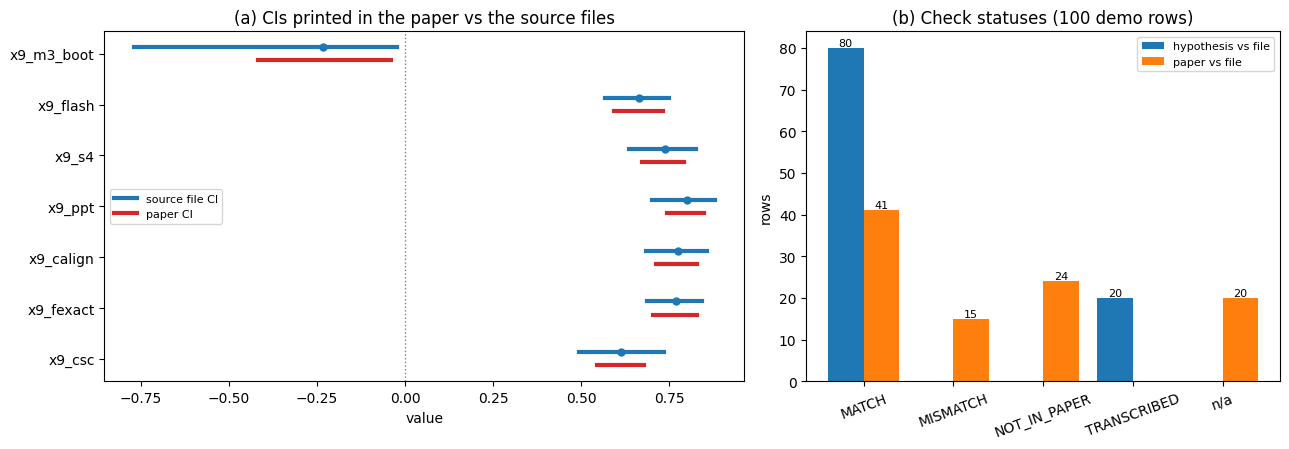

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.35, 1]})

# (a) paper CI vs file CI for every CI-valued paper mismatch
ci_rows = [r for r in rows if r["match_paper_vs_file"] == "MISMATCH" and str(r["paper_value"]).startswith("[") and r["source_ci_raw"]]
ax = axes[0]
for i, r in enumerate(ci_rows):
    lo_p, hi_p = [CK.parse_literal(b)[0] for b in CK.parse_ci(r["paper_value"])]
    lo_f, hi_f = r["source_ci_raw"]
    ax.plot([lo_f, hi_f], [i + 0.13, i + 0.13], color="#1f77b4", lw=3, label="source file CI" if i == 0 else None)
    ax.plot([lo_p, hi_p], [i - 0.13, i - 0.13], color="#d62728", lw=3, label="paper CI" if i == 0 else None)
    ax.plot([r["source_value_raw"]], [i + 0.13], "o", color="#1f77b4", ms=5)
ax.set_yticks(range(len(ci_rows)))
ax.set_yticklabels([r["id"] for r in ci_rows])
ax.axvline(0.5, color="grey", ls=":", lw=1) if all(r["source_ci_raw"][0] > 0 for r in ci_rows) else ax.axvline(0, color="grey", ls=":", lw=1)
ax.set_xlabel("value")
ax.set_title("(a) CIs printed in the paper vs the source files")
ax.legend(loc="center left", fontsize=8)

# (b) status counts
ax = axes[1]
cats = ["MATCH", "MISMATCH", "NOT_IN_PAPER", "TRANSCRIBED", "n/a"]
h = Counter(r["match_hyp_vs_file"] for r in rows)
p = Counter(r["match_paper_vs_file"] for r in rows)
x = range(len(cats))
ax.bar([i - 0.2 for i in x], [h.get(c, 0) for c in cats], 0.4, label="hypothesis vs file", color="#1f77b4")
ax.bar([i + 0.2 for i in x], [p.get(c, 0) for c in cats], 0.4, label="paper vs file", color="#ff7f0e")
for i, c in enumerate(cats):
    for dx, v in ((-0.2, h.get(c, 0)), (0.2, p.get(c, 0))):
        if v:
            ax.text(i + dx, v + 0.5, str(v), ha="center", fontsize=8)
ax.set_xticks(list(x))
ax.set_xticklabels(cats, rotation=20)
ax.set_ylabel("rows")
ax.set_title(f"(b) Check statuses ({len(rows)} demo rows)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [15]:
ref = data["reference"]
aud = ref["full_run_audit_rederive"]
print(f"Full-run independent audit (audit/rederive.py, separate code path from raw per-item files): {aud['n_pass']}/{aud['n_checks']} pass")
display(pd.DataFrame(aud["checks"])[["item", "rederived", "transcribed", "PASS"]])
print("shuffled-label placebo:", aud["placebo_shuffled_labels_c_csc"])

keys = ["n_claims_checked", "n_match", "n_mismatch_hyp_vs_file", "n_match_paper_vs_file", "n_mismatch_paper_vs_file",
        "n_corrections_markers", "lint_failures", "reviewer_items_closed", "reviewer_items_partial", "audit_rederive_pass",
        "checker_mutation_caught", "spend_iter4_evidenced_usd", "spend_iter4_unaccounted_usd", "llm_calls"]
print("\nFull original run, aggregate metrics (eval_out.json):")
display(pd.DataFrame({"metric": keys, "full run": [ref["full_run_metrics_agg"][k] for k in keys]}))

Full-run independent audit (audit/rederive.py, separate code path from raw per-item files): 17/17 pass


,item,rederived,transcribed,PASS
0,exp9 strat AUROC c_csc (pair-weighted within-stratum; exp-9 src de...,0.613644,0.614,True
1,exp9 strat AUROC c_free_exact (pair-weighted within-stratum; exp-9...,0.769728,0.770,True
2,exp9 strat AUROC c_score_align (pair-weighted within-stratum; exp-...,0.774038,0.774,True
3,exp9 CSC e (ERROR rows with c <= 0.5),0.459184,0.459,True
4,exp9 FREE_exact e,0.173469,0.173,True
5,exp9 CSC d (CORRECT rows with c > 0.5),0.139241,0.139,True
6,exp9 FREE_exact d,0.322785,0.323,True
7,exp9 CTRL share of FULL CORRECT rows,0.274306,0.274,True
8,"exp10 base FA at c > 0.5, c_align E",0.712121,0.712,True
9,"exp10 base FA at c > 0.5, FREE3_exact E",0.803468,0.803,True


shuffled-label placebo: {'auroc': 0.4578083554376658, 'ci_B500': [0.40440887060854036, 0.5244085285994009], 'covers_0_5': True}

Full original run, aggregate metrics (eval_out.json):


,metric,full run
0,n_claims_checked,244.000000
1,n_match,244.000000
2,n_mismatch_hyp_vs_file,0.000000
3,n_match_paper_vs_file,153.000000
4,n_mismatch_paper_vs_file,15.000000
5,n_corrections_markers,43.000000
6,lint_failures,0.000000
7,reviewer_items_closed,9.000000
8,reviewer_items_partial,2.000000
9,audit_rederive_pass,17.000000
